## RQ 1.1 How does model size affect overall performance and per-class behavior in facial emotion recognition?

There is a non-linear correlation between model size and overall performance. Despite having more parameters, the average macro-F1 score for small models (1–5B) is higher (0.420) than that of medium models (5-15B), which decreases slightly to 0.396. The Large tier (16–32B) has the best overall performance, with a macro-F1 of 0.606. Therefore, performance does not increase monotonically from Small to Medium, but only shows a noticeable jump at the largest scale assessed.

At the per-class level, emotion-wise behavior varies substantially across size tiers. Happiness consistently achieves the highest F1 across all tiers (0.731 Small, 0.666 Medium, 0.878 Large-Small), while Disgust remains the lowest-performing emotion regardless of model size (0.114 Small, 0.172 Medium, 0.272 Large-Small). Anger, Neutral, and Sadness occupy an intermediate performance band, whereas Fear and Surprise show lower F1 scores in Small and Medium tiers but rise significantly in the Large tier.

Comparing Small (1–5B) to Medium (5-15B) models shows that increased size does not yield uniform gains per emotion. Only Disgust (+50.20%) and Neutral (+2.88%) improve, while Anger (-19.49%), Happiness (-8.84%), Sadness (-8.49%), Fear (-6.77%), and Surprise (-2.54%) all decline. This uneven per-class degradation explains why the Medium tier underperforms the Small tier in macro-F1 despite having more parameters. The mid-tier, therefore, exhibits mixed and often negative scaling effects at the class level.

In contrast, scaling from Small to Large(16-32B) models produces consistent improvements across all emotions. The largest relative gains occur for Disgust (+137.62%), Surprise (+91.11%), and Fear (+75.12%), while Neutral (+46.69%) and Sadness (+41.27%) show moderate gains. Happiness (+20.06%) and Anger (+15.47%) improve to a lesser extent in relative terms but still reach their highest absolute F1 scores at this scale. This suggests that larger models disproportionately benefit emotions that are most difficult to classify at smaller scales.

Overall, model size affects facial emotion recognition in a tier-dependent and emotion-specific manner. Small models outperform Medium models on average, while very large models deliver substantial gains in both macro performance and per-class F1. Low-baseline emotions experience the most significant relative improvements at large scale.



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import json
from datasets import load_dataset



In [2]:
dataset = load_dataset("Emotion-Aware-AI-Assistant/all_models_results_v1")
df = dataset["train"].to_pandas()
print(df.shape)
print(df.columns)
print(df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/44.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33 [00:00<?, ? examples/s]

(33, 42)
Index(['model_name', 'output_method', 'accuracy', 'macro_f1',
       'macro_precision', 'macro_recall', 'weighted_f1', 'weighted_precision',
       'weighted_recall', 'confusion_matrix_json', 'invalid_counts_json',
       'f1_anger', 'f1_disgust', 'f1_fear', 'f1_happiness', 'f1_neutral',
       'f1_sadness', 'f1_surprise', 'precision_anger', 'precision_disgust',
       'precision_fear', 'precision_happiness', 'precision_neutral',
       'precision_sadness', 'precision_surprise', 'recall_anger',
       'recall_disgust', 'recall_fear', 'recall_happiness', 'recall_neutral',
       'recall_sadness', 'recall_surprise', 'wrong_format', 'emotion_refused',
       'emotion_not_listed', 'total_time', 'total_time_hours', 'mean_time',
       'response_time_std', 'response_time_mode', 'tie_counts_json', 'method'],
      dtype='object')
        model_name output_method  accuracy  macro_f1  macro_precision  \
0         deepface          None  0.510464  0.327210         0.399528   
1        l

In [3]:
def extract_metadata(name):
    name = str(name).lower()
    size_match = re.search(r'(\d+\.?\d*)b', name)
    size = float(size_match.group(1)) if size_match else 0.0

    family = name.split(':')[0].split('-')[0].capitalize()
    return pd.Series([size, family])


df[['size_b', 'family']] = df['model_name'].apply(extract_metadata)
bins = [-1, 1, 5, 15, 35]
labels = ['Baseline', 'Small (1-5B)', 'Medium (5-15B)', 'Large-Small (15-35B)']
df['size_tier'] = pd.cut(df['size_b'], bins=bins, labels=labels)

emotions = ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']
f1_cols = [f'f1_{e}' for e in emotions]



In [4]:
print(df[['model_name', 'size_b','family', 'size_tier']].sort_values(by='size_b').to_string(index=False))
print(df['size_tier'].value_counts(dropna=False))

                         model_name  size_b    family            size_tier
                           deepface     0.0  Deepface             Baseline
               qwen3-vl:2b-thinking     2.0     Qwen3         Small (1-5B)
               qwen3-vl:2b-instruct     2.0     Qwen3         Small (1-5B)
               qwen3-vl:2b-instruct     2.0     Qwen3         Small (1-5B)
               qwen3-vl:2b-instruct     2.0     Qwen3         Small (1-5B)
ministral-3:3b-instruct-2512-q4_K_M     3.0 Ministral         Small (1-5B)
                    llava-phi3:3.8b     3.8     Llava         Small (1-5B)
                    llava-phi3:3.8b     3.8     Llava         Small (1-5B)
                    llava-phi3:3.8b     3.8     Llava         Small (1-5B)
               qwen3-vl:4b-instruct     4.0     Qwen3         Small (1-5B)
               qwen3-vl:4b-instruct     4.0     Qwen3         Small (1-5B)
                gemma3:4b-it-q4_K_M     4.0    Gemma3         Small (1-5B)
               qwen3-vl:4

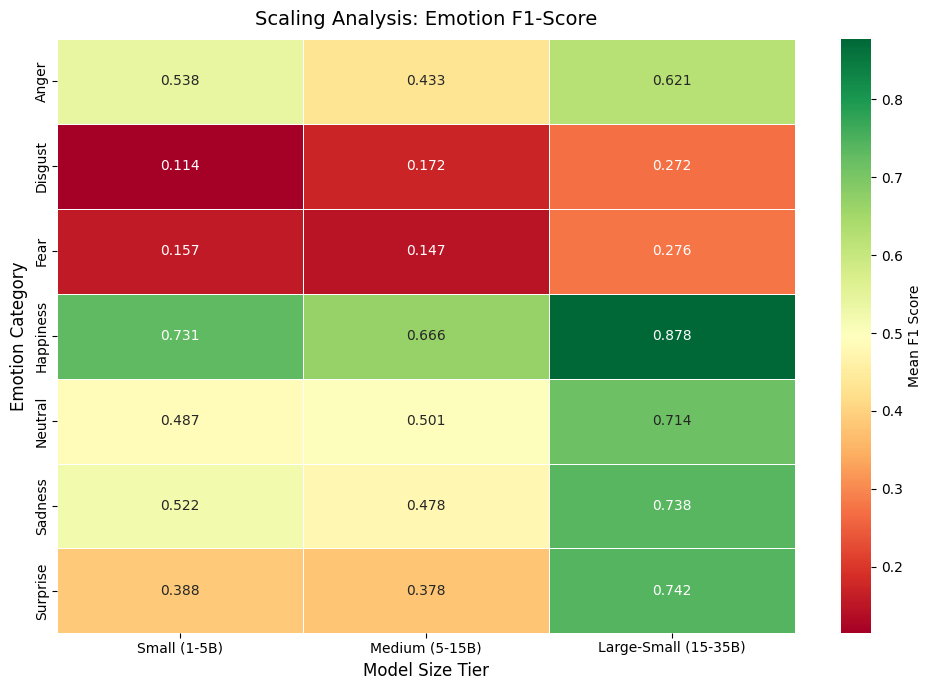

In [5]:
df_discrete = df[df['output_method'] == 'discrete']
scaling_heatmap = df_discrete.groupby('size_tier', observed=True)[f1_cols].mean().T
scaling_heatmap.index = [e.capitalize() for e in emotions]
plt.figure(figsize=(10, 7))

ax = sns.heatmap(
    scaling_heatmap,
    annot=True,
    cmap='RdYlGn',
    fmt=".3f",
    linewidths=.5,
    cbar_kws={'label': 'Mean F1 Score'}
)

plt.title('Scaling Analysis: Emotion F1-Score', fontsize=14, pad=10)
plt.xlabel('Model Size Tier', fontsize=12, labelpad=5)
plt.ylabel('Emotion Category', fontsize=12, labelpad=5)
ax.tick_params(axis='both', which='major', pad=2)

plt.tight_layout()
plt.show()
print()

/tmp/ipython-input-2703909877.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=scaling_dividend.index, y=scaling_dividend.values, palette='RdYlGn_r')


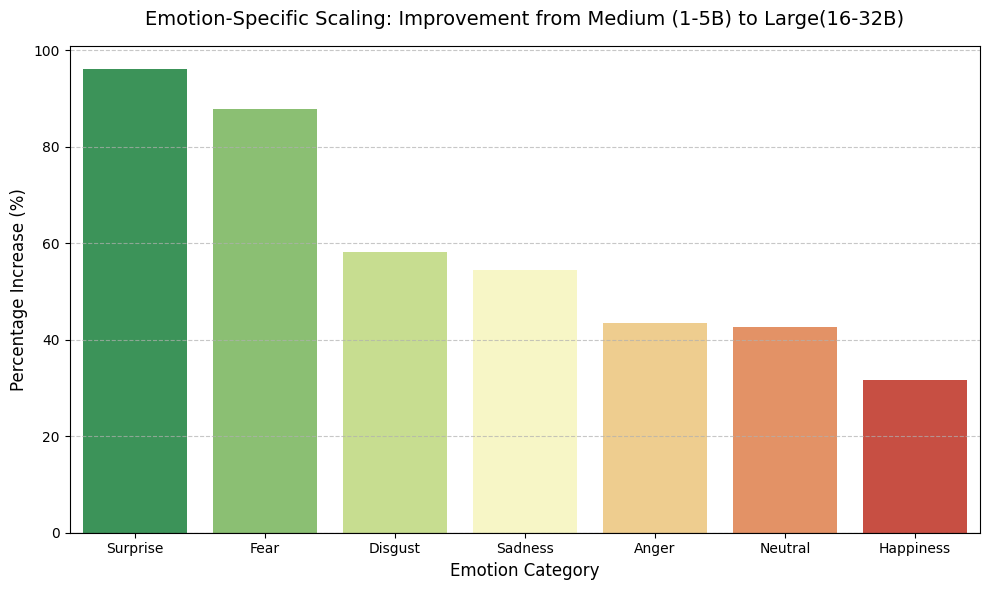

In [7]:
tier_means = df_discrete.groupby('size_tier', observed=True)[f1_cols].mean()
scaling_dividend = ((tier_means.loc['Large-Small (15-35B)'] - tier_means.loc['Medium (5-15B)']) /
                    tier_means.loc['Medium (5-15B)'] * 100)

scaling_dividend = scaling_dividend.sort_values(ascending=False)
scaling_dividend.index = [i.replace('f1_', '').capitalize() for i in scaling_dividend.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=scaling_dividend.index, y=scaling_dividend.values, palette='RdYlGn_r')

plt.title('Emotion-Specific Scaling: Improvement from Medium (1-5B) to Large(16-32B)', fontsize=14, pad=15)
plt.ylabel('Percentage Increase (%)', fontsize=12)
plt.xlabel('Emotion Category', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1856464708.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=improvement_df, x='Emotion', y='Improvement (%)', palette='RdYlGn_r')


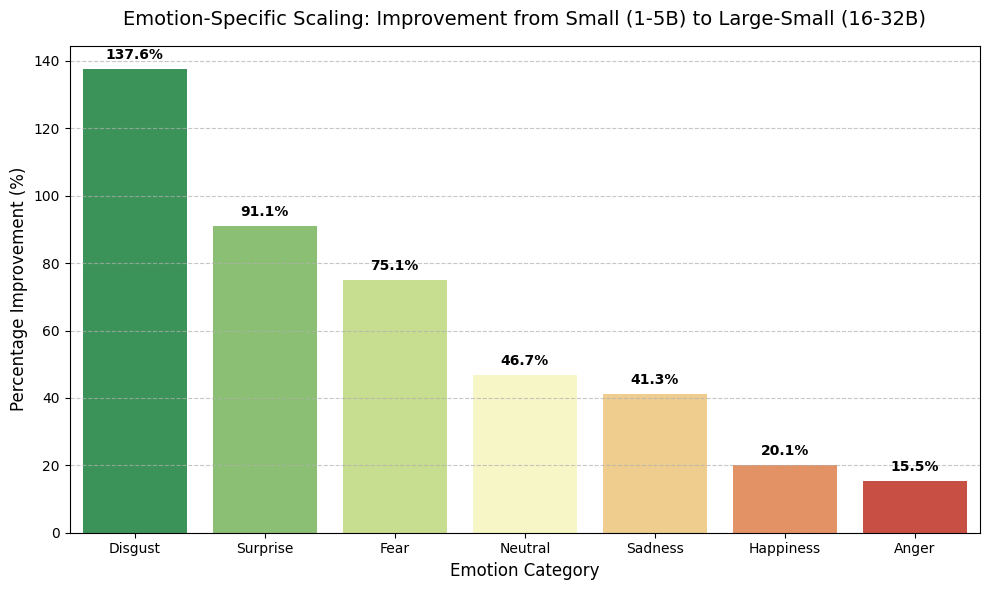

In [8]:
small_label = 'Small (1-5B)'
large_label = 'Large-Small (15-35B)'

improvement = ((tier_means.loc[large_label] - tier_means.loc[small_label]) / tier_means.loc[small_label]) * 100
improvement_df = improvement.to_frame(name='Improvement (%)').reset_index()
improvement_df['Emotion'] = improvement_df['index'].apply(lambda x: x.replace('f1_', '').capitalize())
improvement_df = improvement_df.sort_values(by='Improvement (%)', ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=improvement_df, x='Emotion', y='Improvement (%)', palette='RdYlGn_r')

plt.title('Emotion-Specific Scaling: Improvement from Small (1-5B) to Large-Small (16-32B)', fontsize=14, pad=15)
plt.ylabel('Percentage Improvement (%)', fontsize=12)
plt.xlabel('Emotion Category', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-4178565746.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=imp_mid_df, x='Emotion', y='Improvement (%)', palette='RdYlGn_r')


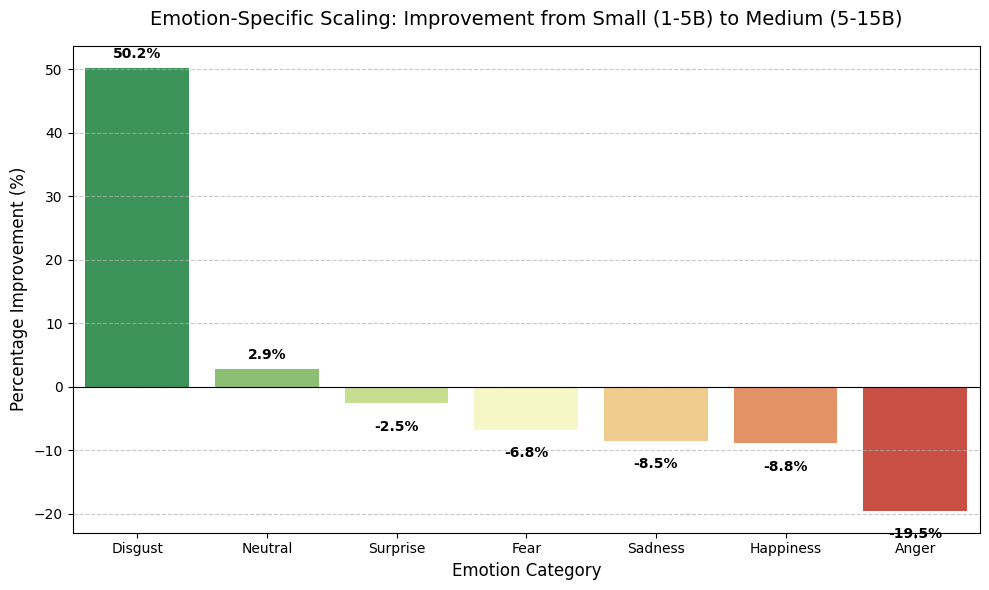

In [9]:

small_label = 'Small (1-5B)'
medium_label = 'Medium (5-15B)'
improvement_mid = ((tier_means.loc[medium_label] - tier_means.loc[small_label]) / tier_means.loc[small_label]) * 100

imp_mid_df = improvement_mid.to_frame(name='Improvement (%)').reset_index()
imp_mid_df['Emotion'] = imp_mid_df['index'].apply(lambda x: x.replace('f1_', '').capitalize())
imp_mid_df = imp_mid_df.sort_values(by='Improvement (%)', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=imp_mid_df, x='Emotion', y='Improvement (%)', palette='RdYlGn_r')

plt.title('Emotion-Specific Scaling: Improvement from Small (1-5B) to Medium (5-15B)', fontsize=14, pad=15)
plt.ylabel('Percentage Improvement (%)', fontsize=12)
plt.xlabel('Emotion Category', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    val = p.get_height()
    ax.annotate(f'{val:.1f}%', (p.get_x() + p.get_width() / 2., val),
                ha='center', va='bottom' if val > 0 else 'top',
                xytext=(0, 5 if val > 0 else -12), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

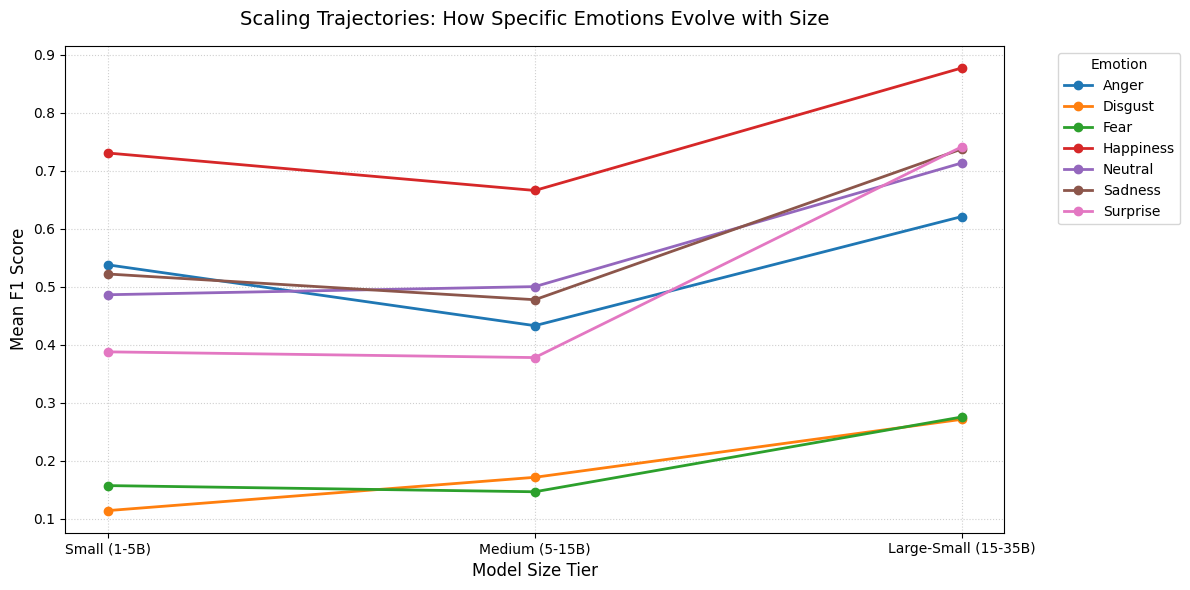

In [10]:
scaling_lines = tier_means.copy()
scaling_lines.index = scaling_lines.index.astype(str)
scaling_lines.columns = [c.replace('f1_', '').capitalize() for c in scaling_lines.columns]

plt.figure(figsize=(12, 6))

for emotion in scaling_lines.columns:
    plt.plot(scaling_lines.index, scaling_lines[emotion], marker='o', label=emotion, linewidth=2)

plt.title('Scaling Trajectories: How Specific Emotions Evolve with Size', fontsize=14, pad=15)
plt.ylabel('Mean F1 Score', fontsize=12)
plt.xlabel('Model Size Tier', fontsize=12)
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

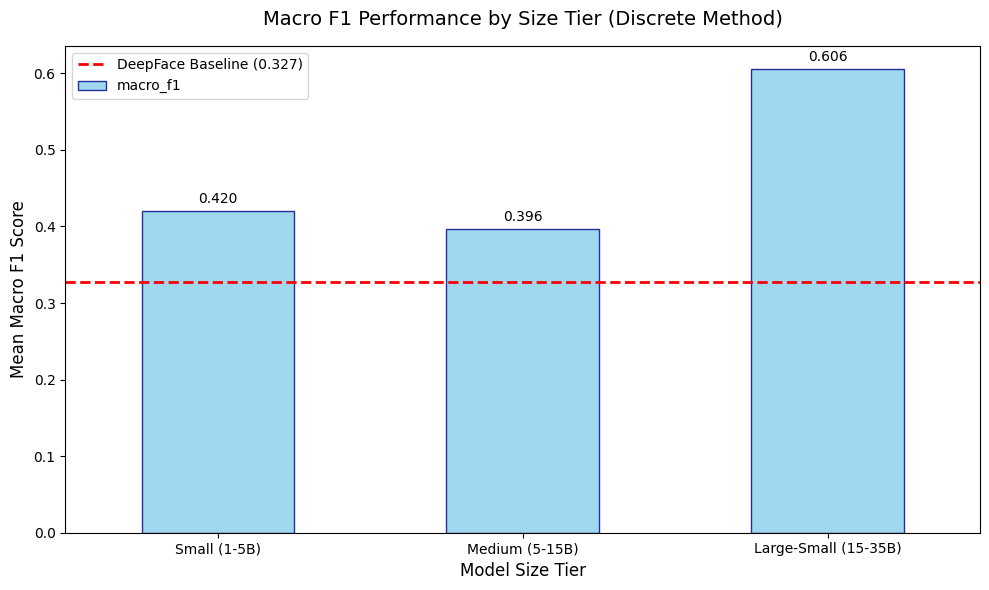

In [11]:
tier_performance = df_discrete.groupby('size_tier', observed=True)['macro_f1'].mean()
baseline_f1 = df[df['model_name'] == 'deepface']['macro_f1'].iloc[0]

plt.figure(figsize=(10, 6))
colors = ['gray' if tier == 'Baseline' else 'skyblue' for tier in tier_performance.index]
ax = tier_performance.plot(kind='bar', color=colors, edgecolor='navy', alpha=0.8)
plt.axhline(y=baseline_f1, color='red', linestyle='--', linewidth=2, label=f'DeepFace Baseline ({baseline_f1:.3f})')

plt.title('Macro F1 Performance by Size Tier (Discrete Method)', fontsize=14, pad=15)
plt.ylabel('Mean Macro F1 Score', fontsize=12)
plt.xlabel('Model Size Tier', fontsize=12)
plt.xticks(rotation=0)
plt.legend()

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()
summary_data = tier_performance.to_frame(name='Mean Macro F1')
summary_data.loc['DeepFace (Ref)'] = baseline_f1

## RQ 1.2 Do different VLLM families exhibit distinct emotion-recognition profiles?

The results clearly show that different VLLM families exhibit distinct behaviors in FER, and these differences are consistent across emotions and model sizes.

Qwen3 clearly stands out as the strongest profile for FER. It has the highest overall macro-F1 score (0.544), and this strength is present across all emotions. Qwen3 performs exceptionally well in detecting Happiness, Neutrality, Sadness, Surprise, and Anger, demonstrating its ability to handle both positive and negative emotions reliably. The deviation scores are positive for every emotion, which means Qwen3 consistently performs above the average of all families. As the model size increases, Qwen3 improves most strongly on difficult emotions, such as Disgust, Fear, and Surprise. So, this indicates that larger Qwen3 models learn finer emotional details.

Llava shows a moderate profile. Its overall performance (macro-F1 = 0.338) is much lower than Qwen3 but better than Gemma3, Ministral, and Minicpm. Llava is strongest at recognizing Happiness, Neutrality, and Sadness, which suggests it handles common and visually apparent emotions comparatively well. However, Fear remains its weakest emotion. As the model scales from small to medium size, Llava shows improvements in Fear and Disgust, but its performance on Happiness decreases. This suggests that scaling helps Llava focus more on harder negative emotions, even if it slightly weakens performance on positive ones.

Gemma3 shows mixed and somewhat unstable behaviour. Its overall macro-F1 score (0.298) is lower than Llava’s, and its performance varies widely across emotions. Gemma3 exhibits moderate performance in Happiness, Neutral, and Sadness, but struggles with less frequent and more complex emotions, such as Disgust, Fear, and Surprise. Most deviation values for Gemma3 are slightly below zero, indicating that its performance is generally at or below the overall average and that it does not clearly do well in any single emotion category. When the model size increases, Surprise and Disgust improve sharply, but Anger, Neutral, and Sadness actually decline. Basically, the improvements in nuanced emotions come at the expense of more common emotional states.

Minstral has a very uneven profile. Although its overall macro-F1 score is low (0.246), it performs surprisingly well in detecting Anger. At the same time, its performance on Neutral is extremely poor, and Disgust and Fear are also weak. The deviation analysis confirms this imbalance, showing a positive bias toward Anger and a strong negative bias for Neutral. This suggests that Ministral is better at detecting strong, high-intensity emotions but fails to understand emotionally subtle or neutral expressions.

Minicpm performs the weakest among all families. It has the lowest macro-F1 score (0.202) and low scores across all emotions, particularly Disgust, Sadness, and Happiness. All deviation values are negative, which means Minicpm consistently performs below the average family level. Unlike other families, it does not show any clear emotional strength or specialization. This indicates limited emotional understanding rather than a specific bias.

Overall, the analysis clearly confirms that different VLLM families exhibit distinct emotion-recognition behaviours. Qwen3 shows a well-balanced and consistently strong profile, performing reliably across both positive and negative emotions without a clear bias toward any single category. Llava demonstrates a preference for common and visually apparent emotions, such as Happiness, Neutrality, and Sadness, while remaining relatively weak in recognizing Fear. Gemma3 is biased toward stable, common emotions and struggles to capture rare or nuanced emotional expressions. Ministral displays a highly skewed profile, with strong sensitivity to high-arousal emotions, such as Anger, but very poor recognition of Neutral and subtle emotions. Minicpm performs weakly across all emotions and does not exhibit any meaningful emotional specialization. These differences suggest that emotion-recognition capability is significantly influenced by family-level design and training characteristics.

In [12]:

df_families = df[df['size_b'] > 0].copy()
family_profiles = df_families.groupby('family')[f1_cols].mean()
family_profiles.columns = [e.capitalize() for e in emotions]
family_rank = df_families.groupby('family')['macro_f1'].mean().sort_values(ascending=False)

print("Overall Performance by Family")
print(family_rank.round(3))

Overall Performance by Family
family
Qwen3        0.544
Llava        0.338
Gemma3       0.298
Ministral    0.246
Minicpm      0.202
Name: macro_f1, dtype: float64


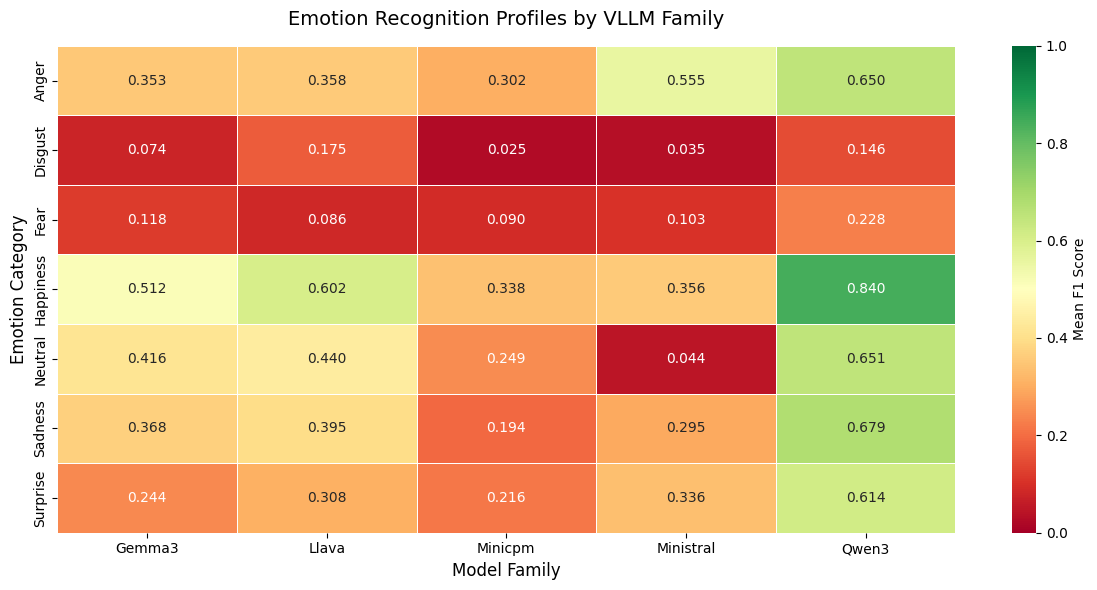

In [13]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    family_profiles.T,
    annot=True,
    cmap='RdYlGn',
    fmt=".3f",
    linewidths=.5,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Mean F1 Score'}
)

plt.title('Emotion Recognition Profiles by VLLM Family', fontsize=14, pad=15)
plt.xlabel('Model Family', fontsize=12)
plt.ylabel('Emotion Category', fontsize=12)
plt.tight_layout()
plt.show()

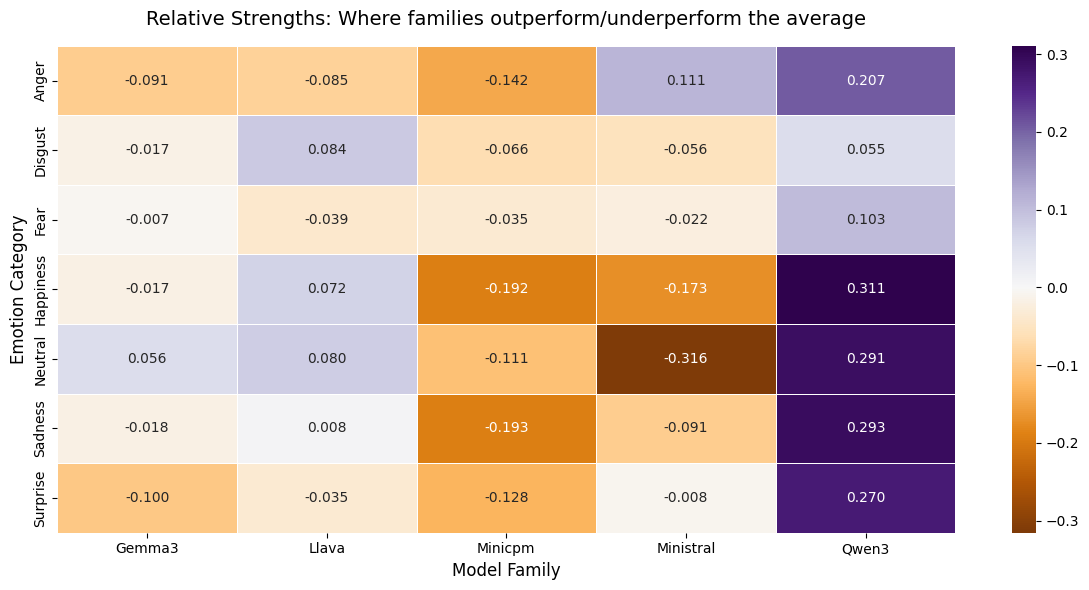

           Anger  Disgust   Fear  Happiness  Neutral  Sadness  Surprise
family                                                                 
Gemma3    -0.091   -0.017 -0.007     -0.017    0.056   -0.018    -0.100
Llava     -0.085    0.084 -0.039      0.072    0.080    0.008    -0.035
Minicpm   -0.142   -0.066 -0.035     -0.192   -0.111   -0.193    -0.128
Ministral  0.111   -0.056 -0.022     -0.173   -0.316   -0.091    -0.008
Qwen3      0.207    0.055  0.103      0.311    0.291    0.293     0.270


In [14]:

mean_performance = family_profiles.mean()
relative_strength = family_profiles - mean_performance

plt.figure(figsize=(12, 6))
sns.heatmap(
    relative_strength.T,
    annot=True,
    cmap='PuOr',
    center=0,
    fmt=".3f",
    linewidths=.5
)

plt.title('Relative Strengths: Where families outperform/underperform the average', fontsize=14, pad=15)
plt.xlabel('Model Family', fontsize=12)
plt.ylabel('Emotion Category', fontsize=12)
plt.tight_layout()
plt.show()
print(relative_strength.round(3))

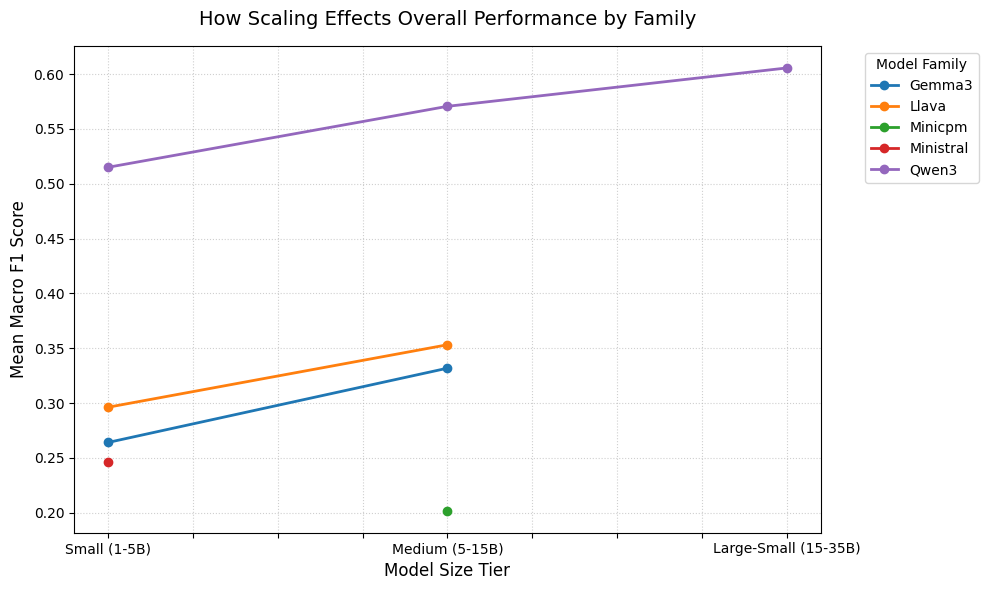

In [15]:

family_scaling = df_families.groupby(['family', 'size_tier'], observed=True)['macro_f1'].mean().unstack(0)
plt.figure(figsize=(10, 6))
family_scaling.plot(marker='o', linewidth=2, ax=plt.gca())

plt.title('How Scaling Effects Overall Performance by Family', fontsize=14, pad=15)
plt.ylabel('Mean Macro F1 Score', fontsize=12)
plt.xlabel('Model Size Tier', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title='Model Family', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [16]:

family_emo_scaling = df_discrete.groupby(['family', 'size_tier'], observed=True)[f1_cols].mean()
families_to_analyze = ['Qwen3', 'Llava', 'Gemma3']
print("Data aggregation complete. Ready for plotting.")

Data aggregation complete. Ready for plotting.


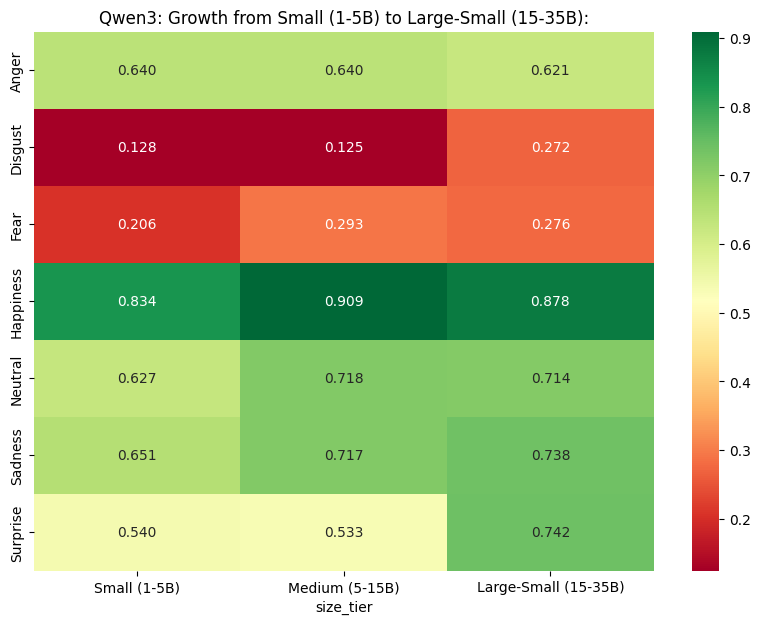

Qwen3 family
           % Improvement
Disgust           113.02
Surprise           37.34
Fear               33.70
Neutral            13.82
Sadness            13.37
Happiness           5.29
Anger              -2.96


In [19]:
fam = 'Qwen3'
if fam in family_emo_scaling.index.get_level_values(0):
    fig, ax = plt.subplots(figsize=(10, 7))
    data = family_emo_scaling.loc[fam].dropna(how='all').T
    data.index = [e.replace('f1_', '').capitalize() for e in data.index]
    sns.heatmap(data, annot=True, cmap='RdYlGn', fmt=".3f", ax=ax)
    ax.set_title(f'{fam}: Growth from {fam_data.index[0]} to {fam_data.index[-1]}:')
    plt.show()
    fam_data = family_emo_scaling.loc[fam].dropna(how='all')
    if len(fam_data) >= 2:
        growth = ((fam_data.iloc[-1] - fam_data.iloc[0]) / fam_data.iloc[0] * 100).round(2)
        growth.index = [e.replace('f1_', '').capitalize() for e in growth.index]
        print(f"{fam} family")
        print(growth.sort_values(ascending=False).to_frame(name='% Improvement'))


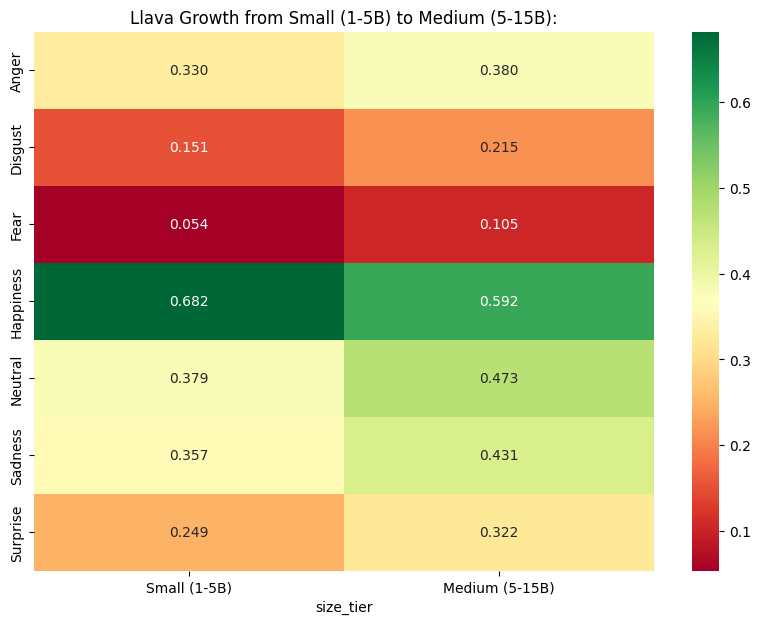

Llava family
           % Improvement
Fear               96.06
Disgust            42.78
Surprise           29.26
Neutral            24.80
Sadness            20.54
Anger              15.10
Happiness         -13.25


In [22]:
fam = 'Llava'
if fam in family_emo_scaling.index.get_level_values(0):
    fig, ax = plt.subplots(figsize=(10, 7))

    data = family_emo_scaling.loc[fam].dropna(how='all').T
    data.index = [e.replace('f1_', '').capitalize() for e in data.index]

    sns.heatmap(data, annot=True, cmap='RdYlGn', fmt=".3f", ax=ax)
    ax.set_title(f'{fam} Growth from {fam_data.index[0]} to {fam_data.index[-1]}:')
    plt.show()

    fam_data = family_emo_scaling.loc[fam].dropna(how='all')
    if len(fam_data) >= 2:
        growth = ((fam_data.iloc[-1] - fam_data.iloc[0]) / fam_data.iloc[0] * 100).round(2)
        growth.index = [e.replace('f1_', '').capitalize() for e in growth.index]
        print(f"{fam} family")
        print(growth.sort_values(ascending=False).to_frame(name='% Improvement'))

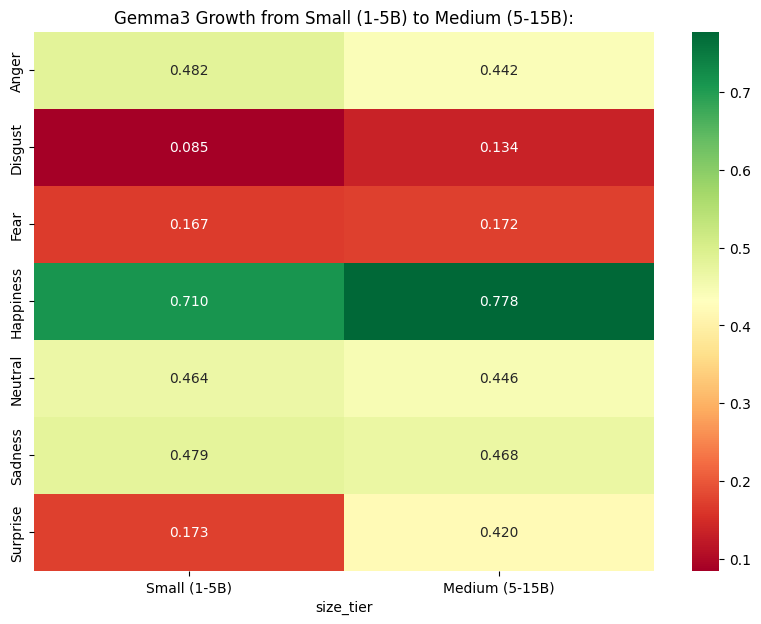

Gemma3 family
           % Improvement
Surprise          142.12
Disgust            58.24
Happiness           9.49
Fear                3.40
Sadness            -2.34
Neutral            -3.89
Anger              -8.38


In [23]:
fam = 'Gemma3'
if fam in family_emo_scaling.index.get_level_values(0):
    fig, ax = plt.subplots(figsize=(10, 7))

    data = family_emo_scaling.loc[fam].dropna(how='all').T
    data.index = [e.replace('f1_', '').capitalize() for e in data.index]

    sns.heatmap(data, annot=True, cmap='RdYlGn', fmt=".3f", ax=ax)
    ax.set_title(f'{fam} Growth from {fam_data.index[0]} to {fam_data.index[-1]}:')
    plt.show()

    fam_data = family_emo_scaling.loc[fam].dropna(how='all')
    if len(fam_data) >= 2:
        growth = ((fam_data.iloc[-1] - fam_data.iloc[0]) / fam_data.iloc[0] * 100).round(2)
        growth.index = [e.replace('f1_', '').capitalize() for e in growth.index]
        print(f"{fam} family")
        print(growth.sort_values(ascending=False).to_frame(name='% Improvement'))